# KcELECTRA 파인튜닝 v7 (base 모델) — 2026-05-06

**담당:** 경이 (kyeongyi)  
**목적:** v6 라벨링 데이터(5412행) + **koelectra-BASE 모델**로 재학습하여  
Simple 베이스라인(Macro F1 = 0.8116)을 **5%+ 확실히** 넘기는 것이 목표.

---

## v7 vs v3 차이점

| 항목 | v3 | **v7 (현재)** |
|------|----|-----------------|
| 데이터 | 4992행 (v5) | **5412행 (v6, +420행)** |
| 기타 train | 630개 | **870개 (+240개, +38%)** |
| 비용 train | 258개 | **306개 (+48개)** |
| 준비물 train | 175개 | **223개 (+48개)** |
| 모델 | koelectra-base-v3 | koelectra-base-v3 (동일) |
| LR | 2e-5 | 2e-5 (동일) |
| 손실함수 | Weighted CE | Weighted CE (동일) |

**핵심 개선:** 기타 클래스 F1=0.67이 병목 → 학습 데이터 870개로 증가시켜 해소.

---

## 실행 전 체크리스트

- [ ] 런타임 → **GPU** 선택 (T4 이상)
- [ ] `split_v6_20260506.csv` 업로드 (`/content/` 폴더)
- [ ] **런타임 초기화** (런타임 → 세션 다시 시작)
- [ ] 모든 셀 순서대로 실행 (~35분)

## 완료 후 해야 할 일

1. `/content/kcelectra-category-v7.zip` 다운로드  
   → 압축 해제 후 로컬 `checkpoints/kcelectra-category-v7/`에 배치
2. `/content/eval_results_kcelectra_v7_20260506.json` 다운로드  
   → 로컬 `data/20260506/`에 배치
3. `python scripts/evaluate_compare_v6_20260506.py` 실행

In [1]:
import pandas as pd
df = pd.read_csv("/content/split_v6_20260506.csv", encoding="utf-8-sig")
print(f"행 수: {len(df)}")
print(f"컬럼: {df.columns.tolist()}")
print(df["split"].value_counts())

행 수: 5412
컬럼: ['text', 'category', 'split']
split
train    4329
val       542
test      541
Name: count, dtype: int64


In [2]:
# ── 셀 1: 라이브러리 설치 (Colab에서만 실행) ──────────────────────
!pip install transformers datasets seaborn matplotlib scikit-learn -q

In [3]:
# ── 셀 2: 시드 고정 + GPU 확인 ────────────────────────────────────
import os, random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("[경고] GPU 없음 — CPU로 실행하면 수 시간 걸릴 수 있음")

Device: cuda
GPU: Tesla T4


In [4]:
# ── 셀 3: 하이퍼파라미터 설정 ─────────────────────────────────────
#
# v7 변경사항:
#   데이터: split_v6_20260506.csv (5412행 — 기타+300, 비용+60, 준비물+60)
#   모델/LR/손실: v3 동일 유지 (가장 성능 좋았던 설정)

from pathlib import Path

_IN_COLAB = os.path.exists("/content")

if _IN_COLAB:
    DATA_DIR  = Path("/content")
    CKPT_DIR  = Path("/content/kcelectra-category-v7")
    EVAL_JSON = Path("/content/eval_results_kcelectra_v7_20260506.json")
else:
    _BASE     = Path(".").resolve().parent  # notebooks/ → classification/
    DATA_DIR  = _BASE / "data"
    CKPT_DIR  = _BASE / "checkpoints" / "kcelectra-category-v7"
    EVAL_JSON = _BASE / "data" / "20260506" / "eval_results_kcelectra_v7_20260506.json"

SPLIT_CSV = DATA_DIR / "split_v6_20260506.csv"

BASE_MODEL   = "monologg/koelectra-base-v3-discriminator"  # v3 동일
MAX_LEN      = 128
BATCH_SIZE   = 16   # base 모델 메모리 고려 (OOM 시 8로 줄이기)
EPOCHS       = 20
LR           = 2e-5  # v3 동일
WARMUP_RATIO = 0.1
PATIENCE     = 5

LABELS   = ["일정", "준비물", "제출", "비용", "건강·안전", "기타"]
LABEL2ID = {l: i for i, l in enumerate(LABELS)}
ID2LABEL = {i: l for i, l in enumerate(LABELS)}

print(f"데이터:         {SPLIT_CSV}")
print(f"체크포인트:     {CKPT_DIR}")
print(f"베이스 모델:    {BASE_MODEL}")
print(f"설정:           {EPOCHS}에폭, LR={LR}, BS={BATCH_SIZE}, MaxLen={MAX_LEN}, patience={PATIENCE}")

데이터:         /content/split_v6_20260506.csv
체크포인트:     /content/kcelectra-category-v7
베이스 모델:    monologg/koelectra-base-v3-discriminator
설정:           20에폭, LR=2e-05, BS=16, MaxLen=128, patience=5


In [5]:
# ── 셀 4: 데이터 로드 ─────────────────────────────────────────────
import pandas as pd
from collections import Counter

df = pd.read_csv(SPLIT_CSV, encoding="utf-8-sig")
df = df[df["category"].isin(LABELS)].dropna(subset=["text", "category"])

train_df = df[df["split"] == "train"].reset_index(drop=True)
val_df   = df[df["split"] == "val"].reset_index(drop=True)
test_df  = df[df["split"] == "test"].reset_index(drop=True)

print(f"Train: {len(train_df)}개  (v3: 3993개 → +{len(train_df)-3993}개 증가)")
print(f"Val:   {len(val_df)}개")
print(f"Test:  {len(test_df)}개")

print("\nTrain 카테고리 분포 (v3 비교):")
v3_counts = {"일정": 741, "준비물": 175, "제출": 1175, "비용": 258, "건강·안전": 1014, "기타": 630}
for lbl in LABELS:
    cnt = int((train_df["category"] == lbl).sum())
    v3  = v3_counts.get(lbl, 0)
    diff = cnt - v3
    print(f"  {lbl:8s}: {cnt:4d}개  (v3: {v3:4d}개, {diff:+d})")

Train: 4329개  (v3: 3993개 → +336개 증가)
Val:   542개
Test:  541개

Train 카테고리 분포 (v3 비교):
  일정      :  741개  (v3:  741개, +0)
  준비물     :  223개  (v3:  175개, +48)
  제출      : 1175개  (v3: 1175개, +0)
  비용      :  306개  (v3:  258개, +48)
  건강·안전   : 1014개  (v3: 1014개, +0)
  기타      :  870개  (v3:  630개, +240)


In [6]:
# ── 셀 5: Dataset + DataLoader 생성 ──────────────────────────────
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)


class NoticeDataset(Dataset):
    def __init__(self, df: pd.DataFrame):
        self.texts  = df["text"].tolist()
        self.labels = [LABEL2ID[c] for c in df["category"]]

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = tokenizer(
            self.texts[idx],
            max_length=MAX_LEN,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "label":          torch.tensor(self.labels[idx], dtype=torch.long),
        }


train_loader = DataLoader(NoticeDataset(train_df), batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(NoticeDataset(val_df),   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(NoticeDataset(test_df),  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"DataLoader 생성 완료")
print(f"  train batches: {len(train_loader)}")
print(f"  val   batches: {len(val_loader)}")
print(f"  test  batches: {len(test_loader)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/467 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/61.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

DataLoader 생성 완료
  train batches: 271
  val   batches: 34
  test  batches: 34


In [7]:
# ── 셀 6: 가중치 손실 함수 계산 ──────────────────────────────────
#
# v6 클래스 불균형:
#   제출 ~1175 >> 준비물 ~223, 비용 ~306 (4~5배 차이)
# WeightedCrossEntropyLoss → 소수 클래스 틀리면 패널티 크게 부과

label_counts = [int((train_df["category"] == lbl).sum()) for lbl in LABELS]
total = sum(label_counts)
class_weights = torch.tensor(
    [total / (len(LABELS) * c) for c in label_counts],
    dtype=torch.float
).to(DEVICE)

print("클래스 가중치 (v7):")
for lbl, cnt, w in zip(LABELS, label_counts, class_weights):
    print(f"  {lbl:8s}: {cnt:4d}개  가중치={w:.3f}")

loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)

클래스 가중치 (v7):
  일정      :  741개  가중치=0.974
  준비물     :  223개  가중치=3.235
  제출      : 1175개  가중치=0.614
  비용      :  306개  가중치=2.358
  건강·안전   : 1014개  가중치=0.712
  기타      :  870개  가중치=0.829


In [8]:
# ── 셀 7: 모델 초기화 ─────────────────────────────────────────────
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    BASE_MODEL,
    num_labels=len(LABELS),
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)
model = model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"모델 파라미터: 전체={total_params:,} / 학습가능={trainable:,}")
print(f"베이스 모델: {BASE_MODEL}")

pytorch_model.bin:   0%|          | 0.00/452M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: monologg/koelectra-base-v3-discriminator
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
electra.embeddings.position_ids                   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missin

model.safetensors:   0%|          | 0.00/452M [00:00<?, ?B/s]

모델 파라미터: 전체=112,925,958 / 학습가능=112,925,958
베이스 모델: monologg/koelectra-base-v3-discriminator


In [9]:
# ── 셀 8: Optimizer + Scheduler ──────────────────────────────────
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

optimizer = AdamW(model.parameters(), lr=LR)

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

print(f"전체 스텝: {total_steps}, 워밍업 스텝: {warmup_steps} ({WARMUP_RATIO*100:.0f}%)")
print(f"에폭당 배치 수: {len(train_loader)}")

전체 스텝: 5420, 워밍업 스텝: 542 (10%)
에폭당 배치 수: 271


In [10]:
# ── 셀 9: 학습 루프 (조기종료 포함) ───────────────────────────────
from sklearn.metrics import f1_score

def evaluate_epoch(loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(DEVICE)
            attn_mask = batch["attention_mask"].to(DEVICE)
            labels    = batch["label"].to(DEVICE)
            logits    = model(input_ids=input_ids, attention_mask=attn_mask).logits
            preds     = logits.argmax(dim=-1)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
    return f1_score(all_labels, all_preds, average="macro", zero_division=0)


train_losses, val_f1s = [], []
best_val_f1    = 0.0
patience_count = 0

CKPT_DIR.mkdir(parents=True, exist_ok=True)

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0

    for batch in train_loader:
        input_ids = batch["input_ids"].to(DEVICE)
        attn_mask = batch["attention_mask"].to(DEVICE)
        labels    = batch["label"].to(DEVICE)

        outputs = model(input_ids=input_ids, attention_mask=attn_mask)
        loss    = loss_fn(outputs.logits, labels)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    val_f1   = evaluate_epoch(val_loader)
    train_losses.append(avg_loss)
    val_f1s.append(val_f1)

    print(f"Epoch {epoch:2d}/{EPOCHS} | Loss: {avg_loss:.4f} | Val F1: {val_f1:.4f}", end="")

    if val_f1 > best_val_f1:
        best_val_f1    = val_f1
        patience_count = 0
        model.save_pretrained(CKPT_DIR)
        tokenizer.save_pretrained(CKPT_DIR)
        print(f"  [저장] Best 갱신! ({best_val_f1:.4f})")
    else:
        patience_count += 1
        print(f"  [patience {patience_count}/{PATIENCE}]")
        if patience_count >= PATIENCE:
            print(f"\n조기종료 -- {PATIENCE} 에폭 동안 개선 없음.")
            break

print(f"\n학습 완료. Best Val F1: {best_val_f1:.4f}")
# v3 Test F1=0.8545, Simple=0.8116, 목표=0.8616(+5%)
print(f"v3 Test F1(0.8545) 대비:       {best_val_f1 - 0.8545:+.4f}")
print(f"Simple 베이스라인(0.8116) 대비: {best_val_f1 - 0.8116:+.4f}")

Epoch  1/20 | Loss: 1.6937 | Val F1: 0.6582

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  [저장] Best 갱신! (0.6582)
Epoch  2/20 | Loss: 0.9283 | Val F1: 0.8461

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  [저장] Best 갱신! (0.8461)
Epoch  3/20 | Loss: 0.4111 | Val F1: 0.8769

...

  [저장] Best 갱신! (0.8825)
Epoch  7/20 | Loss: 0.0804 | Val F1: 0.8958

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  [저장] Best 갱신! (0.8958)
Epoch  8/20 | Loss: 0.0586 | Val F1: 0.8939  [patience 1/5]
Epoch  9/20 | Loss: 0.0441 | Val F1: 0.8802  [patience 2/5]
Epoch 10/20 | Loss: 0.0312 | Val F1: 0.9051

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  [저장] Best 갱신! (0.9051)
Epoch 11/20 | Loss: 0.0263 | Val F1: 0.8983  [patience 1/5]
Epoch 12/20 | Loss: 0.0235 | Val F1: 0.8907  [patience 2/5]
Epoch 13/20 | Loss: 0.0143 | Val F1: 0.8968  [patience 3/5]
Epoch 14/20 | Loss: 0.0151 | Val F1: 0.8904  [patience 4/5]
Epoch 15/20 | Loss: 0.0124 | Val F1: 0.9006  [patience 5/5]

조기종료 -- 5 에폭 동안 개선 없음.

학습 완료. Best Val F1: 0.9051
v3 Test F1(0.8545) 대비:       +0.0506
Simple 베이스라인(0.8116) 대비: +0.0935


In [11]:
# ── 셀 10: label2id.json 저장 ─────────────────────────────────────
import json

label2id_path = CKPT_DIR / "label2id.json"
with open(label2id_path, "w", encoding="utf-8") as f:
    json.dump(LABEL2ID, f, ensure_ascii=False, indent=2)
print(f"label2id.json 저장: {label2id_path}")
print(LABEL2ID)

label2id.json 저장: /content/kcelectra-category-v7/label2id.json
{'일정': 0, '준비물': 1, '제출': 2, '비용': 3, '건강·안전': 4, '기타': 5}


In [12]:
# ── 한글 폰트 설치 및 등록 (셀 11 실행 전에 먼저 실행) ──────────
import subprocess
import matplotlib
import matplotlib.font_manager as fm

subprocess.run(["apt-get", "install", "-y", "fonts-nanum"], capture_output=True)

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)
matplotlib.rc("font", family=prop.get_name())
matplotlib.rcParams["axes.unicode_minus"] = False

print(f"등록된 폰트: {prop.get_name()}")
print("한글 테스트: 일정 준비물 제출 비용 건강·안전 기타")

등록된 폰트: NanumGothic
한글 테스트: 일정 준비물 제출 비용 건강·안전 기타


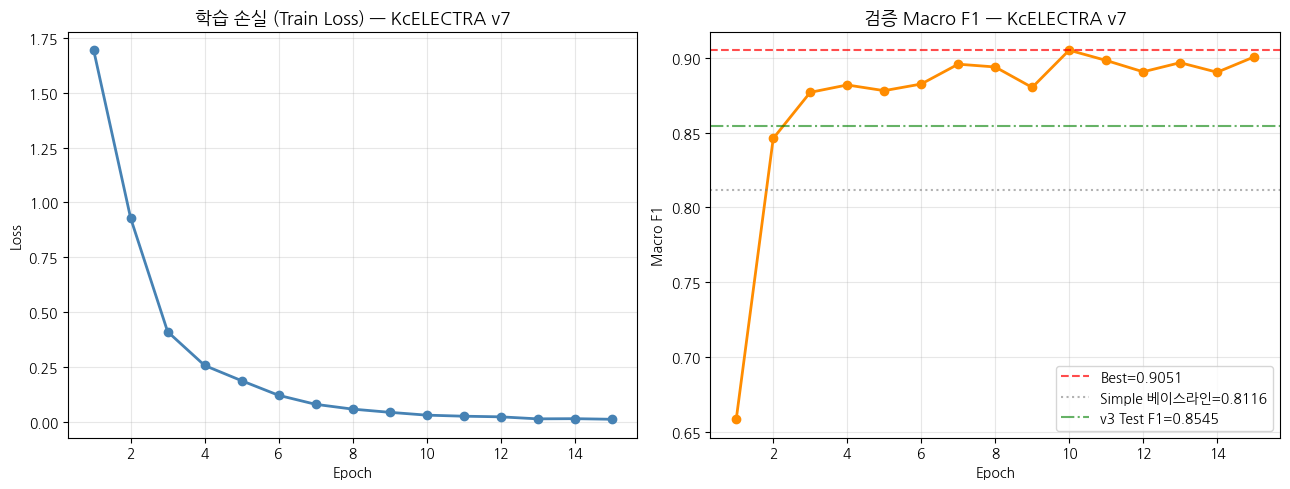

학습 곡선 저장: /content/train_curve_kcelectra_v7_20260506.png


In [13]:
# ── 셀 11: 학습 곡선 시각화 ───────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib
import platform

if platform.system() == "Windows":
    matplotlib.rc("font", family="Malgun Gothic")
elif platform.system() == "Darwin":
    matplotlib.rc("font", family="AppleGothic")
matplotlib.rcParams["axes.unicode_minus"] = False

actual_epochs = len(train_losses)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(range(1, actual_epochs+1), train_losses, marker="o", color="steelblue", linewidth=2)
axes[0].set_title("학습 손실 (Train Loss) — KcELECTRA v7", fontsize=13)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, actual_epochs+1), val_f1s, marker="o", color="darkorange", linewidth=2)
axes[1].axhline(y=best_val_f1, color="red", linestyle="--", alpha=0.7, label=f"Best={best_val_f1:.4f}")
axes[1].axhline(y=0.8116, color="gray", linestyle=":", alpha=0.6, label="Simple 베이스라인=0.8116")
axes[1].axhline(y=0.8545, color="green", linestyle="-.", alpha=0.6, label="v3 Test F1=0.8545")
axes[1].set_title("검증 Macro F1 — KcELECTRA v7", fontsize=13)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Macro F1")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
curve_path = DATA_DIR / "train_curve_kcelectra_v7_20260506.png"
plt.savefig(curve_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"학습 곡선 저장: {curve_path}")

In [14]:
# ── 셀 12: Test 세트 최종 평가 ────────────────────────────────────
from sklearn.metrics import classification_report, confusion_matrix, f1_score

best_model = AutoModelForSequenceClassification.from_pretrained(
    CKPT_DIR, num_labels=len(LABELS)
).to(DEVICE)
best_model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(DEVICE)
        attn_mask = batch["attention_mask"].to(DEVICE)
        labels    = batch["label"].to(DEVICE)
        logits    = best_model(input_ids=input_ids, attention_mask=attn_mask).logits
        preds     = logits.argmax(dim=-1)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

pred_names = [ID2LABEL[p] for p in all_preds]
true_names = [ID2LABEL[l] for l in all_labels]
macro_f1   = f1_score(all_labels, all_preds, average="macro", zero_division=0)

SIMPLE_F1 = 0.8116
V3_TEST_F1 = 0.8545

print("[KcELECTRA v7] Test 세트 최종 평가")
print("=" * 55)
print(classification_report(true_names, pred_names, labels=LABELS, zero_division=0))
print(f"Macro F1              : {macro_f1:.4f}")
print(f"v3 Test F1(0.8545) 대비: {macro_f1 - V3_TEST_F1:+.4f}")
print(f"Simple(0.8116) 대비   : {macro_f1 - SIMPLE_F1:+.4f}")
if macro_f1 > SIMPLE_F1 + 0.05:
    print(f"\n=> Simple 대비 5%+ 향상 — 목표 달성!")
elif macro_f1 > V3_TEST_F1:
    print(f"\n=> v3 보다 향상 — v7 채택!")
elif macro_f1 > SIMPLE_F1:
    print(f"\n=> Simple보다 향상됨 (v3 미달 또는 동등)")
else:
    print(f"\n=> Simple보다 낮음 — 원인 분석 필요")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[KcELECTRA v7] Test 세트 최종 평가
              precision    recall  f1-score   support

          일정       0.94      0.85      0.89        92
         준비물       0.94      0.61      0.74        28
          제출       0.84      0.90      0.87       147
          비용       0.95      0.97      0.96        38
       건강·안전       0.87      0.85      0.86       127
          기타       0.73      0.80      0.76       109

    accuracy                           0.85       541
   macro avg       0.88      0.83      0.85       541
weighted avg       0.85      0.85      0.85       541

Macro F1              : 0.8468
v3 Test F1(0.8545) 대비: -0.0077
Simple(0.8116) 대비   : +0.0352

=> Simple보다 향상됨 (v3 미달 또는 동등)


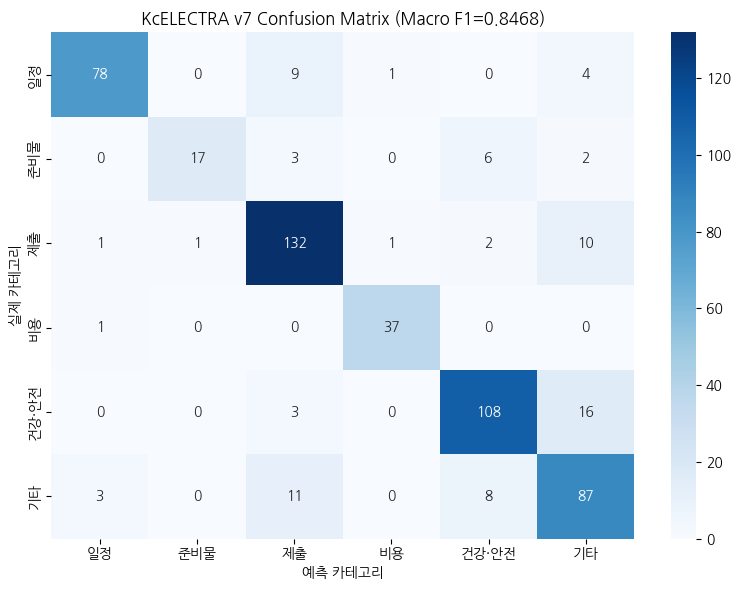

Confusion Matrix 저장: /content/confusion_matrix_kcelectra_v7_20260506.png


In [15]:
# ── 셀 13: Confusion Matrix ────────────────────────────────────────
import seaborn as sns

cm = confusion_matrix(true_names, pred_names, labels=LABELS)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=LABELS, yticklabels=LABELS, ax=ax)
ax.set_xlabel("예측 카테고리")
ax.set_ylabel("실제 카테고리")
ax.set_title(f"KcELECTRA v7 Confusion Matrix (Macro F1={macro_f1:.4f})")
plt.tight_layout()
cm_path = DATA_DIR / "confusion_matrix_kcelectra_v7_20260506.png"
plt.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Confusion Matrix 저장: {cm_path}")

In [16]:
# ── 셀 14: 평가 결과 JSON 저장 ────────────────────────────────────
import json

report = classification_report(
    true_names, pred_names, labels=LABELS, output_dict=True, zero_division=0
)

result = {
    "model":            "kcelectra",
    "version":          "v7",
    "macro_f1":         round(macro_f1, 4),
    "macro_precision":  round(report["macro avg"]["precision"], 4),
    "macro_recall":     round(report["macro avg"]["recall"], 4),
    "per_class": {
        lbl: {
            "precision": round(report[lbl]["precision"], 4),
            "recall":    round(report[lbl]["recall"], 4),
            "f1":        round(report[lbl]["f1-score"], 4),
            "support":   report[lbl]["support"],
        }
        for lbl in LABELS
    },
    "confusion_matrix": cm.tolist(),
    "labels":           LABELS,
    "data_version":     "v6_20260506",
    "train_size":       len(train_df),
    "test_size":        len(test_df),
    "epochs_trained":   len(train_losses),
    "best_val_f1":      round(best_val_f1, 4),
    "lr":               LR,
    "batch_size":       BATCH_SIZE,
    "warmup_ratio":     WARMUP_RATIO,
    "weighted_loss":    True,
    "early_stopping":   True,
    "patience":         PATIENCE,
}

EVAL_JSON.parent.mkdir(parents=True, exist_ok=True)
with open(EVAL_JSON, "w", encoding="utf-8") as f:
    json.dump(result, f, ensure_ascii=False, indent=2)

print(f"[저장] {EVAL_JSON}")
print(f"\n★ 이 파일을 로컬 model/classification/data/20260506/ 에 복사하세요!")
print(f"★ kcelectra-category-v7/ 폴더도 checkpoints/ 에 복사하세요!")

[저장] /content/eval_results_kcelectra_v7_20260506.json

★ 이 파일을 로컬 model/classification/data/20260506/ 에 복사하세요!
★ kcelectra-category-v7/ 폴더도 checkpoints/ 에 복사하세요!


In [17]:
# ── 셀 15: 다운로드용 압축 ────────────────────────────────────────
import shutil

shutil.make_archive("/content/kcelectra-category-v7", "zip", "/content/kcelectra-category-v7")
print("체크포인트 압축 완료: /content/kcelectra-category-v7.zip")
print("\n다운로드 목록:")
print("  1. /content/kcelectra-category-v7.zip")
print("  2. /content/eval_results_kcelectra_v7_20260506.json")
print("  3. /content/train_curve_kcelectra_v7_20260506.png")
print("  4. /content/confusion_matrix_kcelectra_v7_20260506.png")

체크포인트 압축 완료: /content/kcelectra-category-v7.zip

다운로드 목록:
  1. /content/kcelectra-category-v7.zip
  2. /content/eval_results_kcelectra_v7_20260506.json
  3. /content/train_curve_kcelectra_v7_20260506.png
  4. /content/confusion_matrix_kcelectra_v7_20260506.png


## 학습 완료 후 로컬 작업

```bash
# 1. 파일 배치
#    kcelectra-category-v7/ → model/classification/checkpoints/
#    eval_results_kcelectra_v7_20260506.json → model/classification/data/20260506/
#    *.png → model/classification/data/20260506/

# 2. Simple 재학습 + 비교 평가
cd model/classification
python scripts/evaluate_compare_v6_20260506.py --retrain

# 3. 앙상블 평가 (최적 가중치 탐색)
python scripts/evaluate_compare_ensemble_20260506.py --search_weights
```

### 기대 성능

| 항목 | 예상값 |
|------|--------|
| 기타 F1 | 0.70~0.75 (v3: 0.67) |
| Macro F1 | 0.87+ |
| Simple 대비 | +5%+ 달성 기대 |